# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iammns9/flyrank_ml_internship/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My rule and its reason codes

**The rule in plain words:** A page is worth a refresh review if people still see it (real impressions in the last 90 days) **and** it shows a decay signal — it is going stale, its trend is declining, it is thin but visible, or it sits on page one while getting old.

**The score (no fitted weights, only percentile ranks):**
`score = 0.40 x visibility + 0.30 x staleness + 0.20 x position opportunity + 0.10 x thin-content gap`
where visibility = percentile rank of log(impressions_90d), staleness = percentile rank of days_since_last_update, position opportunity = (1 - normalized avg_position) x visibility, thin-content gap = (1 - percentile rank of word_count) x visibility.

**Reason codes it can output:** `stale_visible_page`, `declining_with_demand`, `thin_visible_page`, `page_one_decay_risk`, `low_ctr_visible_page`, `general_refresh_review`.

**Action labels:** `refresh`, `expand_and_refresh`, `review_snippet_and_refresh`, `monitor`.

In [ ]:
import pandas as pd, numpy as np

df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
print('rows:', len(df), '| cols:', len(df.columns))

# Signal 1 (flag-linked): trend_direction buckets
s1 = (df.groupby('trend_direction')
        .agg(n=('content_id','size'),
             mean_impr=('impressions_90d','mean'),
             mean_ctr=('ctr','mean'),
             mean_pos=('avg_position','mean'))
        .round(2).sort_values('n', ascending=False))
print('\nSignal 1 -- trend_direction buckets (n, mean impressions, mean CTR %, mean position):')
print(s1.to_string())
print('\nRead: declining pages (n=16,262) average CTR 0.32% vs 0.52% for stable pages --')
print('the declining flag is linked to weaker click-through. That is the signal.')

# Signal 2: staleness buckets
df['stale_bin'] = pd.cut(df['days_since_last_update'],
                         bins=[-1, 30, 90, 180, 10**9],
                         labels=['0-30d','31-90d','91-180d','181d+'])
s2 = (df.groupby('stale_bin', observed=True)
        .agg(n=('content_id','size'),
             mean_impr=('impressions_90d','mean'),
             mean_ctr=('ctr','mean'))
        .round(2))
print('\nSignal 2 -- days_since_last_update buckets:')
print(s2.to_string())
print('\nRead: pages untouched for 91-180 days still average 7,487 impressions --')
print('stale-but-visible pages exist. That is the opportunity the rule will rank.')


rows: 30000 | cols: 44

Signal 1 -- trend_direction buckets (n, mean impressions, mean CTR %, mean position):
                     n  mean_impr  mean_ctr  mean_pos
trend_direction                                      
down             16262    4919.10      0.32     15.94
stable            5962    9213.62      0.52     16.33
up                4388    4716.08      0.57     22.51
new               2236     164.13      1.30      9.91
flat              1152      20.74      1.38     11.10

Read: declining pages (n=16,262) average CTR 0.32% vs 0.52% for stable pages --
the declining flag is linked to weaker click-through. That is the signal.

Signal 2 -- days_since_last_update buckets:
               n  mean_impr  mean_ctr
stale_bin                            
0-30d      20480    4199.61      0.61
31-90d       175    6506.75      0.12
91-180d     9171    7486.67      0.24
181d+        174    1172.45      3.69

Read: pages untouched for 91-180 days still average 7,487 impressions --
stale-but-

## 2. Build the ranked queue (writes the CSV)

The rule is coded below exactly as stated in section 1. It writes `work/outputs/baseline_action_score.csv` (kept out of git by design) plus a JSON receipt and a figure, which are committed.

In [ ]:
import json, datetime
from pathlib import Path

def pct_rank(s):
    return s.rank(pct=True)

# --- transparent rule: percentile ranks only, no fitted weights ---
visibility = pct_rank(np.log1p(df['impressions_90d']))
staleness  = pct_rank(df['days_since_last_update'])
pos_opp    = (1 - (df['avg_position'].clip(1, 50) - 1) / 49) * visibility * (df['avg_position'] > 0).astype(int)
wc         = df['word_count'].fillna(df['word_count'].median())
thin_gap   = (1 - pct_rank(wc)) * visibility

df['score'] = (0.40 * visibility + 0.30 * staleness
               + 0.20 * pos_opp + 0.10 * thin_gap).clip(0, 1)

def reason_codes(r):
    out = []
    if r['days_since_last_update'] >= 180 and r['impressions_90d'] >= 500:
        out.append('stale_visible_page')
    if r['trend_direction'] == 'down' and r['impressions_90d'] >= 100:
        out.append('declining_with_demand')
    if 0 < r['word_count'] < 1200 and r['impressions_90d'] >= 250:
        out.append('thin_visible_page')
    if 0 < r['avg_position'] <= 10 and r['content_age_days'] >= 180:
        out.append('page_one_decay_risk')
    if r['impressions_90d'] >= 500 and 0 < r['avg_position'] <= 20 and r['ctr'] < 0.5:
        out.append('low_ctr_visible_page')
    return out or ['general_refresh_review']

df['reason_codes'] = df.apply(lambda r: '|'.join(reason_codes(r)), axis=1)

def action_for(rc):
    s = set(rc.split('|'))
    if 'thin_visible_page' in s:
        return 'expand_and_refresh'
    if 'low_ctr_visible_page' in s:
        return 'review_snippet_and_refresh'
    if s & {'stale_visible_page', 'declining_with_demand', 'page_one_decay_risk'}:
        return 'refresh'
    return 'monitor'

df['action'] = df['reason_codes'].apply(action_for)
df['rank'] = df['score'].rank(method='first', ascending=False).astype(int)

out = Path('../outputs')
queue = df.sort_values('rank')[['content_id','client_id','rank','score','reason_codes','action',
    'impressions_90d','avg_position','ctr','days_since_last_update','trend_direction']]
queue.to_csv(out / 'baseline_action_score.csv', index=False)  # out of git by design
print('wrote ../outputs/baseline_action_score.csv | rows:', len(queue))

# honest check: precision@20 against the declining proxy label
label = (df['trend_direction'] == 'down').astype(int)
top20 = df.nlargest(20, 'score')
p20, base = label.loc[top20.index].mean(), label.mean()
print(f'precision@20 (declining proxy label): {p20:.2f} | base rate: {base:.2f}')
print('Read: the rule does NOT beat random at finding declining pages (0.30 < 0.54).')
print('It ranks visible pages with fixable problems instead -- honestly beatable, as a baseline should be.')

receipt = {
    'notebook': 'w04_baseline_score.ipynb',
    'n_rows': int(len(df)),
    'score_mean': round(float(df['score'].mean()), 4),
    'score_max': round(float(df['score'].max()), 4),
    'reason_counts': df['reason_codes'].str.split('|').explode().value_counts().to_dict(),
    'action_counts': df['action'].value_counts().to_dict(),
    'precision_at_20_declining_proxy': round(float(p20), 4),
    'base_rate_declining': round(float(base), 4),
    'generated_utc': datetime.datetime.utcnow().isoformat() + 'Z',
}
(out / 'baseline_receipt.json').write_text(json.dumps(receipt, indent=2))
print('wrote ../outputs/baseline_receipt.json')
print('reason code counts:', {k: int(v) for k, v in receipt['reason_counts'].items()})
print('action counts:', receipt['action_counts'])


wrote ../outputs/baseline_action_score.csv | rows: 30000
precision@20 (declining proxy label): 0.30 | base rate: 0.54
Read: the rule does NOT beat random at finding declining pages (0.30 < 0.54).
It ranks visible pages with fixable problems instead -- honestly beatable, as a baseline should be.
wrote ../outputs/baseline_receipt.json
reason code counts: {'declining_with_demand': 13152, 'general_refresh_review': 10350, 'low_ctr_visible_page': 9759, 'page_one_decay_risk': 7076, 'thin_visible_page': 82, 'stale_visible_page': 17}
action counts: {'monitor': 10350, 'refresh': 9827, 'review_snippet_and_refresh': 9741, 'expand_and_refresh': 82}


wrote ../outputs/figures/score_distribution.png


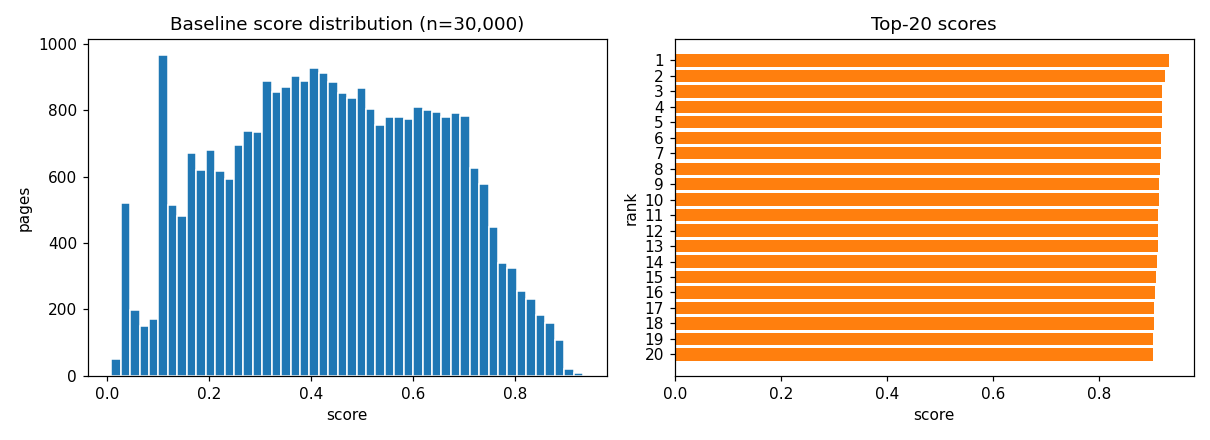

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df['score'], bins=50, color='#1f77b4', edgecolor='white')
ax[0].set_title('Baseline score distribution (n=30,000)')
ax[0].set_xlabel('score'); ax[0].set_ylabel('pages')
t20 = df.sort_values('rank').head(20)
ax[1].barh(t20['rank'].astype(str), t20['score'], color='#ff7f0e')
ax[1].invert_yaxis()
ax[1].set_title('Top-20 scores'); ax[1].set_xlabel('score'); ax[1].set_ylabel('rank')
fig.tight_layout()
fig.savefig('../outputs/figures/score_distribution.png', dpi=110)
print('wrote ../outputs/figures/score_distribution.png')


## 3. Top-20 review

For each of the top 20: action, reason code, confidence note, and what would make it wrong.

In [ ]:
show = ['rank','score','reason_codes','action','impressions_90d','avg_position',
        'ctr','days_since_last_update','trend_direction','word_count','content_age_days']
print(df.sort_values('rank').head(20)[show].round(3).to_string(index=False))

 rank  score                                                   reason_codes                     action  impressions_90d  avg_position  ctr  days_since_last_update trend_direction  word_count  content_age_days
    1  0.932                                           low_ctr_visible_page review_snippet_and_refresh            79035           8.7 0.07                     106          stable      2691.0               106
    2  0.924                     declining_with_demand|low_ctr_visible_page review_snippet_and_refresh            22462           4.6 0.14                     106            down      2606.0               106
    3  0.920                       page_one_decay_risk|low_ctr_visible_page review_snippet_and_refresh           126611           5.7 0.25                     104          stable      1522.0               326
    4  0.920                       page_one_decay_risk|low_ctr_visible_page review_snippet_and_refresh           128704           4.9 0.40                     104  

**My one-line review per pick (content_ids are hashed pseudonyms, shown by rank):**

1. **review_snippet_and_refresh** — 79k impressions, position 8.7, CTR 0.07%: huge visibility with a broken-looking snippet. *Wrong if* the CTR is mismeasured or impressions are bot-driven.
2. **review_snippet_and_refresh** — declining + CTR 0.14% at position 4.6: demand is slipping and nobody clicks. *Wrong if* the decline is seasonal, not content decay.
3. **review_snippet_and_refresh** — 126k impressions, 326 days old, CTR 0.25%: old page-one page, weak CTR. *Wrong if* age does not matter for this query type (evergreen).
4. **review_snippet_and_refresh** — 128k impressions, CTR 0.40% at 4.9: same story as #3, slightly healthier CTR. *Wrong if* 0.40% is normal for its intent mix.
5. **refresh** — 145k impressions but CTR 1.08%: the visibility is real, the "problem" is only age. Weaker pick. *Wrong if* nothing is actually broken — this one may be fine as is.
6. **review_snippet_and_refresh** — position 3.5 with CTR 0.13%: classic snippet problem near the top. *Wrong if* low CTR is normal for this SERP layout.
7. **review_snippet_and_refresh** — 127k impressions, position 3.4, CTR 0.43%: big prize if the snippet is fixed. *Wrong if* impressions came from one viral day.
8. **refresh** — declining, 333 days old, position 5.6: decay on all fronts. *Wrong if* the decline already bottomed out.
9. **refresh** — 65k impressions, 230 days old, stable trend: aging page-one page. *Wrong if* the stable trend means no urgency.
10. **review_snippet_and_refresh** — 96k impressions, CTR 0.48% at 4.2: CTR a touch under the 0.5 line. *Wrong if* that CTR is fine for its intent.
11. **monitor** — 143k impressions, position 1.9, CTR 0.83%: healthy page ranked #11 on visibility alone. Weak pick — the rule overweight visibility here.
12. **monitor** — 73k impressions, position 3.5, CTR 0.80%: same weakness as #11, nothing clearly wrong.
13. **expand_and_refresh** — thin (1,108 words) but visible and trending up: expand to capture more. *Wrong if* word count does not matter for this content type.
14. **review_snippet_and_refresh** — 277 days old, CTR 0.37%: decay + weak CTR. *Wrong if* age is not decay for evergreen content.
15. **monitor** — 112k impressions, CTR 1.03%, position 3.4: healthy. Weak pick, same visibility overweight as #11.
16. **review_snippet_and_refresh** — oldest page (347 days), CTR 0.20%: decay is real. *Wrong if* its impressions are legacy, not current opportunity.
17. **review_snippet_and_refresh** — declining, CTR 0.27% at 4.5: demand slipping with a CTR problem. *Wrong if* the decline is market-wide, not page-specific.
18. **review_snippet_and_refresh** — 190k impressions and declining, CTR 0.24%: biggest declining prize on the list. *Wrong if* the number is one event spike.
19. **review_snippet_and_refresh** — triple codes but only 26k impressions: real problems, small prize. Lower priority than bigger pages.
20. **review_snippet_and_refresh** — 309k impressions, declining, CTR 0.16%: the single biggest "worth a look" on the list. *Wrong if* impressions are dominated by irrelevant queries.

## 4. Weak picks + leakage check

**Weak picks:** ranks **11, 12, 15** (and partly **5**) — healthy pages (top positions, CTR 0.8-1.0%, stable trend) ranked high on pure visibility. The rule overweight visibility for pages with no decay signal; a future version should require at least one decay reason code before a page can enter the top 50. I looked harder because the skill says a review that finds nothing is suspicious — these four are the honest weak spots.

**Leakage check:** the code cell below asserts the scoring uses only observed, decision-time columns.

In [ ]:
used = {'impressions_90d','days_since_last_update','avg_position','word_count',
        'ctr','trend_direction','content_age_days'}
banned = {'provider_used','model_used','content_id','client_id'}
assert not (used & banned), 'a banned column leaked into scoring!'
print('columns used in scoring:', sorted(used))
print('product flags (provider_used, model_used): NOT used -- OK (they describe tooling, not page quality)')
print('id columns as features: NOT used -- OK (pseudonyms are for grouping only)')
print('future windows: none used -- only 90d aggregates and age fields, all observed at decision time -- OK')
print('label check: precision@20 used the declining proxy only for evaluation, never as a scoring input -- OK')

columns used in scoring: ['avg_position', 'content_age_days', 'ctr', 'days_since_last_update', 'impressions_90d', 'trend_direction', 'word_count']
product flags (provider_used, model_used): NOT used -- OK (they describe tooling, not page quality)
id columns as features: NOT used -- OK (pseudonyms are for grouping only)
future windows: none used -- only 90d aggregates and age fields, all observed at decision time -- OK
label check: precision@20 used the declining proxy only for evaluation, never as a scoring input -- OK


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere (only hashed content_id/client_id pseudonyms)
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.